# 04 · REINFORCE → PPO → evaluate walking

**Prepared comparison: PPO at 50 and 100 total updates of the same run.**
No cells were executed for this preparation. Existing outputs are prior results.

In the **C-1N pairing** kernel:
1. For a fresh run, run Hyperparameter tuning, Setup, and sections 1–6 in order.
2. Run section 7 to reach 50 total updates.
3. Run section 9 to continue the same run to 100. Section 8 is optional.
4. Run the two Checkpoint comparison cells to evaluate and open the four-pane viewer.

If the current kernel already holds this run, keep its state and run sections 7
and 9, then the comparison cells. Do not rerun initialization between blocks.
The run cells use total targets, so rerunning them does not add another 50 or 100.
STRIDE remains unearned.

[Frozen REINFORCE evidence](../history/notebooks/04_reinforce_before_ppo_20260914.ipynb).
Do not use Run All: the reference appendix resets shared names.


In [19]:
# Hyperparameter tuning
# Run this cell before setup. Changing settings does not update existing optimizers.

# Task, collection and exploration.
SETTINGS = dict(horizon=250, physics_steps=10, bound_rad=0.05, std=0.30,
                fall_height_m=0.25, gamma=0.99, learning_rate=3e-4,
                batch_episodes=4, initialization_seed=23, train_seed=1000,
                eval_seeds=[101, 102, 103], deterministic=False)

# PPO.
PPO = dict(gamma=SETTINGS['gamma'], gae_lambda=0.95, clip_ratio=0.2,
           actor_lr=3e-4, critic_lr=1e-3, epochs=4, minibatch_size=250,
           max_grad_norm=0.5, target_kl=0.01, train_seed=2000,
           eval_seeds=list(range(201, 213)))

# Reward weights.
REWARD = dict(progress=1.0, height=0.1)

# Total update targets for one continuous run (not additional updates).
TRAINING_UPDATES = 50
TOTAL_UPDATES = 100

# Fixed-shuffle reference only.
COXA_SWEEP_RAD = 0.04
LIFT_RAD = 0.05
GAIT_PERIOD_S = 0.8

# Evaluate saved weights from this run on identical seeds.
EVAL_CHECKPOINTS = [50, 100]


## Setup

Use the **C-1N pairing** kernel. Run setup and the carried code once.

In [20]:
from pathlib import Path
import sys

REPO_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                 if (p / "spider" / "learning.py").is_file())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import mujoco
import numpy as np
import pandas as pd
from IPython.display import display
from spider.learning import LearningSimulation, record_policy, plot_recordings
from spider.simulation import neutral_targets

sim = LearningSimulation()
actuator_names = [sim.model.actuator(i).name for i in range(sim.model.nu)]
print("Physics timestep (s):", sim.model.opt.timestep)
display(pd.DataFrame({
    "index": range(sim.model.nu), "actuator": actuator_names,
    "neutral_rad": neutral_targets(),
    "target_min_rad": sim.model.actuator_ctrlrange[:, 0],
    "target_max_rad": sim.model.actuator_ctrlrange[:, 1],
}))

Physics timestep (s): 0.002


,index,actuator,neutral_rad,target_min_rad,target_max_rad
0,0,front_left_coxa_motor,0.0,-0.8,0.8
1,1,front_left_hip_motor,-0.2,-0.8,0.8
2,2,front_left_knee_motor,1.1,-1.4,1.4
3,3,front_right_coxa_motor,0.0,-0.8,0.8
4,4,front_right_hip_motor,-0.2,-0.8,0.8
5,5,front_right_knee_motor,1.1,-1.4,1.4
6,6,middle_left_coxa_motor,0.0,-0.8,0.8
7,7,middle_left_hip_motor,-0.2,-0.8,0.8
8,8,middle_left_knee_motor,1.1,-1.4,1.4
9,9,middle_right_coxa_motor,0.0,-0.8,0.8


### Fixed-shuffle comparison setup

Geometry and fixed control from notebook 03 (`e6ba912`). These cells do not train
or step physics. The learned actor uses direct joint offsets, not this gait.

In [21]:
from spider.simulation import FOOT_NAMES

probe_sim = LearningSimulation()  # Separate scratch state; preserves the policy runs.
PROBE_DELTA_RAD = 0.01
PROBE_JOINTS = ("coxa", "hip", "knee")


def foot_at_offset(leg, joint, offset_rad):
    """Geometry helper: one joint offset from neutral -> foot XYZ in torso frame (m)."""
    probe_sim.reset()
    model, data = probe_sim.model, probe_sim.data
    joint_id = model.joint(f"{leg}_{joint}").id
    address = model.jnt_qposadr[joint_id]
    data.qpos[address] += offset_rad  # Set an angle directly; this is not an actuator command.
    mujoco.mj_forward(model, data)  # Recompute geometry without advancing time.
    torso_id = model.body("torso").id
    foot_id = model.geom(f"{leg}_foot").id
    rotation = data.xmat[torso_id].reshape(3, 3)
    return (rotation.T @ (data.geom_xpos[foot_id] - data.xpos[torso_id])).copy()


def foot_motion_per_radian(leg, joint, delta=PROBE_DELTA_RAD):
    """Return a 3-vector: local foot motion [dx/dq, dy/dq, dz/dq], in m/rad."""
    # Two-sided finite difference; retain the diagnostics when changing this probe.
    plus = foot_at_offset(leg, joint, delta)
    minus = foot_at_offset(leg, joint, -delta)
    return (plus - minus) / (2 * delta)

In [22]:
# Geometry-informed tripod gait.
# This is a hypothesis / visualization, not an earned locomotion result.

import numpy as np

LEGS = (
    "front_left",
    "front_right",
    "middle_left",
    "middle_right",
    "rear_left",
    "rear_right",
)

TRIPOD_A = {"front_left", "middle_right", "rear_left"}
TRIPOD_B = set(LEGS) - TRIPOD_A

# Small offsets. Keep this boring initially.


# Learn local directions from geometry instead of guessing signs.
geometry = {}

for leg in LEGS:
    coxa_j = foot_motion_per_radian(leg, "coxa")

    hip_j = foot_motion_per_radian(leg, "hip")
    knee_j = foot_motion_per_radian(leg, "knee")

    lift_joint, lift_j = max(
        [("hip", hip_j), ("knee", knee_j)],
        key=lambda item: abs(item[1][2]),
    )

    # sign that makes the foot move backward in torso +X coordinates
    backward_sign = -np.sign(coxa_j[0])

    # sign that makes the selected joint move the foot upward (+Z)
    lift_sign = np.sign(lift_j[2])

    geometry[leg] = {
        "backward_sign": backward_sign,
        "lift_joint": lift_joint,
        "lift_sign": lift_sign,
        "dx_dq": coxa_j[0],
        "dz_dq": lift_j[2],
    }

geometry

{'front_left': {'backward_sign': np.float64(1.0),
  'lift_joint': 'hip',
  'lift_sign': np.float64(-1.0),
  'dx_dq': np.float64(-0.24872537012312346),
  'dz_dq': np.float64(-0.12003818291465296)},
 'front_right': {'backward_sign': np.float64(-1.0),
  'lift_joint': 'hip',
  'lift_sign': np.float64(-1.0),
  'dx_dq': np.float64(0.24872537012312346),
  'dz_dq': np.float64(-0.12003818291465296)},
 'middle_left': {'backward_sign': np.float64(1.0),
  'lift_joint': 'hip',
  'lift_sign': np.float64(-1.0),
  'dx_dq': np.float64(-0.4039969692622954),
  'dz_dq': np.float64(-0.12003818291465573)},
 'middle_right': {'backward_sign': np.float64(-1.0),
  'lift_joint': 'hip',
  'lift_sign': np.float64(-1.0),
  'dx_dq': np.float64(0.4039969692622954),
  'dz_dq': np.float64(-0.12003818291465573)},
 'rear_left': {'backward_sign': np.float64(1.0),
  'lift_joint': 'hip',
  'lift_sign': np.float64(-1.0),
  'dx_dq': np.float64(-0.24872537012312484),
  'dz_dq': np.float64(-0.1200381829146474)},
 'rear_right': 

In [23]:
def geometry_gait(state):
    offsets = np.zeros(18)

    phase = 2 * np.pi * state.time / GAIT_PERIOD_S

    for leg_index, leg in enumerate(LEGS):
        # Opposite phase for alternating tripods.
        leg_phase = phase if leg in TRIPOD_A else phase + np.pi

        swing = np.sin(leg_phase) > 0

        info = geometry[leg]

        coxa_index = leg_index * 3
        hip_index = coxa_index + 1
        knee_index = coxa_index + 2

        # stance: push foot backward
        # swing: bring foot forward
        direction = -1 if swing else 1

        offsets[coxa_index] = (
            direction
            * info["backward_sign"]
            * COXA_SWEEP_RAD
        )

        # Lift only during swing.
        if swing:
            lift_index = hip_index if info["lift_joint"] == "hip" else knee_index
            offsets[lift_index] = info["lift_sign"] * LIFT_RAD

    return offsets

## 1 · Actor, critic and fixed task — run

The actor maps 47 observations to 18 latent means. The critic maps the same observation
to one remaining-return estimate. Both use two 64-unit tanh layers. Start the actor
from the preserved initialization; evaluate the trained REINFORCE checkpoint separately.

Keep the original reward, action map, fixed standard deviation 0.30 and 5-second
finite-horizon task. Both falls and that horizon end rewards: **no bootstrap at either**.
An external cutoff in a continuing task would bootstrap; that is a different contract.
Time is absent from the inherited observation, a known limitation for a finite-horizon critic.

PPO settings below are declared starting settings, not tuned gait coefficients.
Clip 0.2, actor lr 3e-4 and KL target 0.01 follow familiar PPO practice; four minibatch
epochs are a bounded first schedule. Fixed exploration is retained to isolate this change.
[Standard PPO equations](https://spinningup.openai.com/en/latest/algorithms/ppo.html#key-equations).

In [24]:
# INITIALIZE A FRESH RUN. Rerunning resets learning; no robot rollout runs here.
import copy
from pathlib import Path
import numpy as np
import pandas as pd
import inspect
import hashlib
import json
from datetime import datetime, timezone
from importlib.metadata import version
import torch
from torch import nn
from torch.distributions import Normal
from IPython.display import display
from lab.reinforce_inspection import collect, summary, save_episode, gradient_table, plot_evaluations


# Draft finite-horizon task: fall/horizon ends rewards; no bootstrap.
# Start with notebook 03's 0.05 rad bound. Settings remain editable.


from lab.ppo_inspection import frozen_batch, policy_diagnostics, save_batch
from spider.recording import launch_replay_grid
BASELINE = REPO_ROOT / 'telemetry/reinforce-debug/20260915T010216441278Z'

with torch.random.fork_rng(devices=[]):
    torch.manual_seed(23)
    actor = nn.Sequential(nn.Linear(47,64), nn.Tanh(), nn.Linear(64,64), nn.Tanh(), nn.Linear(64,18))
    critic = nn.Sequential(nn.Linear(47,64), nn.Tanh(), nn.Linear(64,64), nn.Tanh(), nn.Linear(64,1))
actor.load_state_dict(torch.load(BASELINE/'initial.pt', weights_only=True)['actor'])
initial_actor = copy.deepcopy(actor)
reinforce_actor = copy.deepcopy(actor)
reinforce_actor.load_state_dict(torch.load(BASELINE/'block-00000/checkpoint-00020.pt', weights_only=True)['actor'])
actor_optimizer = torch.optim.Adam(actor.parameters(), lr=PPO['actor_lr'])
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=PPO['critic_lr'])
ppo_updates, ppo_log = 0, []
ppo_directory = REPO_ROOT/'telemetry/ppo'/datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
ppo_directory.mkdir(parents=True, exist_ok=False)
(ppo_directory/'settings.json').write_text(json.dumps(dict(task=SETTINGS, ppo=PPO, reward=REWARD), indent=2))
torch.save(dict(actor=actor.state_dict(), critic=critic.state_dict()), ppo_directory/'initial.pt')
print('Fresh PPO run:', ppo_directory)
print('Actor batch shape:', actor(torch.zeros(3,47)).shape, 'Critic:', critic(torch.zeros(3,47)).squeeze(-1).shape)


Fresh PPO run: c:\Users\haidm\Desktop\robotics\spider\telemetry\ppo\20260915T152940537445Z
Actor batch shape: torch.Size([3, 18]) Critic: torch.Size([3])


### Inherited task functions — run unchanged
These are your corrected functions, reused as the fixed comparison contract.

In [25]:
# EDITABLE LEARNING FUNCTIONS. No training executes in this cell.
def observation_from(state):
    return torch.tensor([*state.torso_velocity, *state.torso_angular_velocity,
                         *state.torso_orientation, *state.joint_positions,
                         *state.joint_velocities, state.torso_position[2]], dtype=torch.float32)


def sample_action(network, observation, std, deterministic=False):
    distribution = Normal(network(observation), std)
    latent = distribution.mean if deterministic else distribution.sample()
    log_prob = distribution.log_prob(latent).sum()
    return latent, log_prob


def reward_terms(before, offsets_rad, after):
    return {
        'progress': REWARD['progress'] * float(after.torso_velocity[0]),
        'height': REWARD['height'] * float(after.torso_position[2]),
    }



## 2 · Collect frozen records — run once

Four fresh episodes per update: up to 1,000 transitions. `obs [N,47]`, `actions [N,18]`;
`old_logp`, rewards, old values and next values are `[N]`, detached. Old log-probs score
the saved **latent sample**. Reuse that same sample in PPO; never resample it during updates.
The fixed tanh action map stays unchanged. This cell runs robot physics, not training.

In [26]:
def collect_ppo_batch():
    episodes = []
    folder = ppo_directory / f'rollout-{ppo_updates:05d}-{datetime.now(timezone.utc).strftime("%H%M%S%f")}'
    folder.mkdir()
    for index in range(SETTINGS['batch_episodes']):
        episode = collect(actor, observation_from, sample_action, reward_terms, SETTINGS,
                          seed=PPO['train_seed'] + ppo_updates*SETTINGS['batch_episodes'] + index,
                          label=f'PPO rollout {ppo_updates} episode {index}')
        save_episode(episode, folder/f'{index:02d}')
        episodes.append(episode)
    batch = frozen_batch(episodes, critic)
    save_batch(batch, folder/'batch.npz')
    return batch, episodes

batch, episodes = collect_ppo_batch()
display(pd.DataFrame([summary(e) for e in episodes]))
with torch.no_grad():
    check_logp = Normal(actor(batch['obs']), SETTINGS['std']).log_prob(batch['actions']).sum(-1)
torch.testing.assert_close(check_logp, batch['old_logp'])
print({k: tuple(v.shape) for k,v in batch.items()})

,treatment,seed,seconds,forward_m,sideways_m,minimum_height_m,total_reward,terminated,truncated,clipped_targets
0,PPO rollout 0 episode 0,2000,5.0,-0.033156,0.007645,0.447151,9.673413,False,True,0
1,PPO rollout 0 episode 1,2001,5.0,-0.017517,0.057797,0.448617,10.486489,False,True,0
2,PPO rollout 0 episode 2,2002,5.0,0.041938,0.107423,0.448820,13.422079,False,True,0
3,PPO rollout 0 episode 3,2003,5.0,-0.076475,0.009940,0.448236,7.501904,False,True,0


{'obs': (1000, 47), 'actions': (1000, 18), 'old_logp': (1000,), 'rewards': (1000,), 'values': (1000,), 'next_values': (1000,), 'episode_end': (1000,), 'bootstrap_allowed': (1000,)}


## 3 · GAE and value targets — verify

For each row: $\delta_t=r_t+\gamma b_t V(s_{t+1})-V(s_t)$.
Backward recurrence: $A_t=\delta_t+\gamma\lambda(1-e_t)A_{t+1}$, starting from zero.
`b = bootstrap_allowed`, `e = episode_end`. Target is $A_t+V(s_t)$.
Return raw advantages and targets, both detached `[N]`. Normalize advantages once
over the whole rollout **after** constructing targets; never normalize targets.
[GAE §3](https://arxiv.org/abs/1506.02438).

In [27]:
def gae_targets(
    rewards,
    values,
    next_values,
    bootstrap_allowed,
    episode_end,
    gamma,
    lam,
):
    # TD error:
    # δ_t = r_t + γ b_t V(s_{t+1}) - V(s_t)
    deltas = (
        rewards
        + gamma * bootstrap_allowed * next_values
        - values
    )

    advantages = torch.empty_like(rewards)
    future_advantage = rewards.new_zeros(())

    # GAE:
    # A_t = δ_t + γλ(1 - e_t)A_{t+1}
    for t in range(len(rewards) - 1, -1, -1):
        if episode_end[t]:
            future_advantage = deltas[t]
        else:
            future_advantage = (
                deltas[t]
                + gamma * lam * future_advantage
            )

        advantages[t] = future_advantage
    targets = advantages + values
    return advantages.detach(), targets.detach()

In [28]:
def attach_targets(batch):
    advantages, targets = gae_targets(batch['rewards'], batch['values'], batch['next_values'],
        batch['bootstrap_allowed'], batch['episode_end'], PPO['gamma'], PPO['gae_lambda'])
    batch['targets'] = targets.detach()
    batch['advantages'] = ((advantages-advantages.mean()) / (advantages.std(unbiased=False)+1e-8)).detach()
    return batch

batch = attach_targets(batch)
display(pd.DataFrame({k: batch[k].numpy() for k in ['rewards','values','targets','advantages']}).describe())

,rewards,values,targets,advantages
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,0.041084,0.079872,0.688355,4.577637e-08
std,0.076887,0.083505,0.454608,1.000500e+00
min,-0.171598,-0.198091,-0.368586,-2.611899e+00
25%,-0.010273,0.024401,0.374407,-7.118425e-01
50%,0.040249,0.083849,0.674853,-3.753290e-02
75%,0.091476,0.138243,0.936610,5.470930e-01
max,0.328936,0.350142,2.292854,3.622150e+00


### 3 checkpoint · verify GAE before PPO
Run after target assembly. Checks the current rollout against TD and episodic-return identities; no training.

In [29]:
# GAE baseline diagnostic: saved/current rollout only; no physics or optimizer steps.
raw_advantages, value_targets = gae_targets(
    batch['rewards'], batch['values'], batch['next_values'],
    batch['bootstrap_allowed'], batch['episode_end'], PPO['gamma'], PPO['gae_lambda'])
assert raw_advantages.shape == value_targets.shape == batch['rewards'].shape
assert torch.isfinite(raw_advantages).all() and torch.isfinite(value_targets).all()
assert not raw_advantages.requires_grad and not value_targets.requires_grad
assert not batch['advantages'].requires_grad and not batch['targets'].requires_grad
torch.testing.assert_close(value_targets, raw_advantages + batch['values'])
torch.testing.assert_close(batch['targets'], value_targets)

# Lambda=0 must reduce to the one-step TD error.
a0, _ = gae_targets(batch['rewards'], batch['values'], batch['next_values'],
    batch['bootstrap_allowed'], batch['episode_end'], PPO['gamma'], 0.)
td_error = batch['rewards'] + PPO['gamma']*batch['bootstrap_allowed']*batch['next_values'] - batch['values']
torch.testing.assert_close(a0, td_error)

# Lambda=1 must recover the existing finite-episode discounted-return baseline.
assert torch.equal(batch['bootstrap_allowed'], ~batch['episode_end'])
assert batch['episode_end'][-1]
_, lambda_one_targets = gae_targets(batch['rewards'], batch['values'], batch['next_values'],
    batch['bootstrap_allowed'], batch['episode_end'], PPO['gamma'], 1.)
return_reference = torch.empty_like(batch['rewards'])
future_return = batch['rewards'].new_zeros(())
for t in range(len(return_reference)-1, -1, -1):
    if batch['episode_end'][t]:
        future_return = batch['rewards'].new_zeros(())
    future_return = batch['rewards'][t] + PPO['gamma']*future_return
    return_reference[t] = future_return
torch.testing.assert_close(lambda_one_targets, return_reference, atol=1e-5, rtol=1e-5)

# Evaluate episodes separately: later episodes must not affect earlier credit.
start = 0
for end in torch.where(batch['episode_end'])[0].tolist():
    section = slice(start, end+1)
    isolated, _ = gae_targets(batch['rewards'][section], batch['values'][section],
        batch['next_values'][section], batch['bootstrap_allowed'][section],
        batch['episode_end'][section], PPO['gamma'], PPO['gae_lambda'])
    torch.testing.assert_close(isolated, raw_advantages[section])
    start = end+1
normalized_reference = (raw_advantages-raw_advantages.mean())/(raw_advantages.std(unbiased=False)+1e-8)
torch.testing.assert_close(batch['advantages'], normalized_reference)
display(pd.DataFrame({
    'check': ['Finite detached vectors', 'Value targets = raw advantage + old value',
              'Lambda=0 equals TD error', 'Lambda=1 equals episodic returns',
              'No cross-episode credit', 'Only actor advantages normalized'],
    'result': ['PASS']*6,
}))
print(f"GAE baseline verified on {len(raw_advantages)} transitions / {int(batch['episode_end'].sum())} episodes. Ready for section 4.")


,check,result
0,Finite detached vectors,PASS
1,Value targets = raw advantage + old value,PASS
2,Lambda=0 equals TD error,PASS
3,Lambda=1 equals episodic returns,PASS
4,No cross-episode credit,PASS
5,Only actor advantages normalized,PASS


GAE baseline verified on 1000 transitions / 4 episodes. Ready for section 4.


## 4 · PPO actor loss and critic loss — verify

$\rho=\exp(\log p_{new}-\log p_{old})$.
$L_\pi=-\operatorname{mean}[\min(\rho A,\operatorname{clip}(\rho,1-\epsilon,1+\epsilon)A)]$.
$L_V=\operatorname{mean}[(V-target)^2]$.

Use fresh network predictions and frozen rollout targets. Sum Gaussian log-prob
over 18 actions only (`dim=-1`). Clipping is neither actuator clipping nor a hard
bound on every probability ratio. Fixed std means entropy is diagnostic only here.
[PPO §3](https://arxiv.org/abs/1707.06347).

In [30]:
def clipped_policy_loss(new_logp, old_logp, advantages, epsilon):
    # Inputs [B]; return scalar loss using the equation above.
    ratio = torch.exp(new_logp - old_logp)
    surrogate = ratio * advantages
    clipped_ratio = torch.clamp(ratio, 1.0 - epsilon, 1.0 + epsilon)
    clipped_surrogate = clipped_ratio * advantages
    policy_loss = -torch.mean(torch.min(clipped_surrogate, surrogate))
    return policy_loss


def critic_loss(predicted_values, targets):
    # Both [B], not [B,1] against [B]. Return scalar mean squared error.
    L_v = torch.mean((predicted_values - targets) ** 2)
    return L_v

### 4 checkpoint · verify losses before updating weights
Analytic checks only. No robot rollout or optimizer step.

In [31]:
# Analytic cases check both advantage signs and both clipping limits.
new_logp = torch.tensor([1.5, 0.5, 1.5, 0.5]).log().requires_grad_()
loss = clipped_policy_loss(new_logp, torch.zeros(4), torch.tensor([1., 1., -1., -1.]), 0.2)
torch.testing.assert_close(loss, torch.tensor(0.15))
loss.backward()
torch.testing.assert_close(new_logp.grad, torch.tensor([0., -0.125, 0.375, 0.]))

# Critic regression must have the correct scalar loss and prediction gradients.
predictions = torch.tensor([1., 3.], requires_grad=True)
value_loss = critic_loss(predictions, torch.tensor([2., 1.]))
torch.testing.assert_close(value_loss, torch.tensor(2.5))
value_loss.backward()
torch.testing.assert_close(predictions.grad, torch.tensor([-1., 2.]))

# Equal policies give ratio=1; zero advantages must produce zero actor gradients.
equal_logp = torch.zeros(3, requires_grad=True)
zero_loss = clipped_policy_loss(equal_logp, torch.zeros(3), torch.zeros(3), 0.2)
zero_loss.backward()
torch.testing.assert_close(zero_loss, torch.tensor(0.))
torch.testing.assert_close(equal_logp.grad, torch.zeros(3))
display(pd.DataFrame({
    'check': ['PPO loss and clipping gradients', 'Critic loss and gradients', 'Zero-advantage actor update'],
    'result': ['PASS'] * 3,
}))
print('Section 4 verified. Next: section 5, one minibatch update.')

,check,result
0,PPO loss and clipping gradients,PASS
1,Critic loss and gradients,PASS
2,Zero-advantage actor update,PASS


Section 4 verified. Next: section 5, one minibatch update.


## 5 · One minibatch update — implement

1. Form `Normal(actor(obs), std)` and score saved actions with `.sum(-1)`.
2. Calculate actor loss; zero actor gradients, backpropagate, clip gradient norm,
   then step `actor_optimizer`.
3. Predict `critic(obs).squeeze(-1)`; calculate value loss and update the critic
   with its own optimizer and gradient clipping.
4. Return detached numeric `actor_loss`, `critic_loss`, `actor_grad_norm`,
   `critic_grad_norm`. No `retain_graph`; every minibatch gets a fresh graph.

In [32]:
def debug_minibatch(
    minibatch, distribution, new_logp, actor_loss, predicted_values,
    value_loss, actor_parameter_grad_norms, report,
):
    """Print the diagnostics from one completed update; never update weights."""
    print("obs:", minibatch['obs'].shape)
    print("actions:", minibatch['actions'].shape)
    print("old_logp:", minibatch['old_logp'].shape)
    print("advantages:", minibatch['advantages'].shape)

    # Actor predictions and gradients.
    print("distribution mean:", distribution.mean.shape)
    print("new_logp:", new_logp.shape)
    print("new_logp finite:", torch.isfinite(new_logp).all().item())
    print("new_logp requires_grad:", new_logp.requires_grad)
    print("actor_loss:", actor_loss.item())
    print("actor_loss shape:", actor_loss.shape)
    print("actor_loss requires_grad:", actor_loss.requires_grad)
    for name, norm in actor_parameter_grad_norms.items():
        print(name, "grad:", norm)
    print("actor grad norm:", report['actor_grad_norm'])

    # Critic predictions and gradients.
    print("predicted_values:", predicted_values.shape)
    print("targets:", minibatch['targets'].shape)
    print("predicted_values requires_grad:", predicted_values.requires_grad)
    print("critic_loss:", value_loss.item())
    print("critic_loss requires_grad:", value_loss.requires_grad)
    print("critic grad norm:", report['critic_grad_norm'])

    print(report)


def update_minibatch(minibatch):
    # Frozen rollout inputs; only the current network predictions carry gradients.
    obs = minibatch['obs']                  # [B, 47]
    actions = minibatch['actions']          # [B, 18], saved latent samples
    old_logp = minibatch['old_logp']         # [B]
    advantages = minibatch['advantages']    # [B]
    targets = minibatch['targets']          # [B]

    # 1. Actor: score the saved actions under the current policy.

    distribution = Normal(actor(obs), SETTINGS['std'])

    # Sum over action dimensions, keeping one log-probability per sample.
    new_logp = distribution.log_prob(actions).sum(dim=-1)

    actor_loss = clipped_policy_loss(
        new_logp,
        old_logp,
        advantages,
        PPO['clip_ratio'],
    )

    # Build fresh gradients for this minibatch, then clip and apply them.
    actor_optimizer.zero_grad(set_to_none=True)
    actor_loss.backward()

    # Capture per-parameter norms before clipping for optional diagnostics.
    actor_parameter_grad_norms = {
        name: None if param.grad is None else param.grad.norm().item()
        for name, param in actor.named_parameters()
    }

    # The returned norm is the total norm before clipping.
    actor_grad_norm = torch.nn.utils.clip_grad_norm_(
        actor.parameters(), PPO['max_grad_norm'],
    )

    actor_optimizer.step()

    # 2. Critic: fit [B] predictions to the frozen [B] value targets.
    predicted_values = critic(obs).squeeze(-1)

    value_loss = critic_loss(
        predicted_values,
        targets,
    )

    critic_optimizer.zero_grad(set_to_none=True)
    value_loss.backward()

    critic_grad_norm = torch.nn.utils.clip_grad_norm_(
        critic.parameters(), PPO['max_grad_norm'],
    )

    critic_optimizer.step()

    # 3. Report: plain numbers, detached from the computation graphs.
    report = {
        "actor_loss": actor_loss.detach().item(),
        "critic_loss": value_loss.detach().item(),
        "actor_grad_norm": actor_grad_norm.detach().item(),
        "critic_grad_norm": critic_grad_norm.detach().item(),
    }
    # Uncomment to print the diagnostics for this update.
    # debug_minibatch(
    #     minibatch, distribution, new_logp, actor_loss, predicted_values,
    #     value_loss, actor_parameter_grad_norms, report,
    # )
    return report


# Scratch inspection: the two calls below each perform a real update.
B = 4

real_minibatch = {
    "obs": batch["obs"][:B],
    "actions": batch["actions"][:B],
    "old_logp": batch["old_logp"][:B],
    "advantages": batch["advantages"][:B],
    "targets": batch["targets"][:B],
}

update_minibatch(real_minibatch)
report = update_minibatch(real_minibatch)

In [33]:
# Section 5 diagnostic: prove one minibatch update actually updates both networks.

import copy

B = 32

test_minibatch = {
    "obs": batch["obs"][:B],
    "actions": batch["actions"][:B],
    "old_logp": batch["old_logp"][:B],
    "advantages": batch["advantages"][:B],
    "targets": batch["targets"][:B],
}

# Preserve state so this diagnostic does not permanently train the run.
actor_before = copy.deepcopy(actor.state_dict())
critic_before = copy.deepcopy(critic.state_dict())
actor_optimizer_before = copy.deepcopy(actor_optimizer.state_dict())
critic_optimizer_before = copy.deepcopy(critic_optimizer.state_dict())

report = update_minibatch(test_minibatch)

actor_change = torch.sqrt(sum(
    (actor.state_dict()[name] - actor_before[name]).square().sum()
    for name in actor_before
)).item()

critic_change = torch.sqrt(sum(
    (critic.state_dict()[name] - critic_before[name]).square().sum()
    for name in critic_before
)).item()

print("report:", report)
print("actor weight change:", actor_change)
print("critic weight change:", critic_change)

assert np.isfinite(report["actor_loss"])
assert np.isfinite(report["critic_loss"])
assert np.isfinite(report["actor_grad_norm"])
assert np.isfinite(report["critic_grad_norm"])

assert actor_change > 0, "Actor weights did not change"
assert critic_change > 0, "Critic weights did not change"

print("One PPO minibatch update passed")

# Restore pre-test state.
actor.load_state_dict(actor_before)
critic.load_state_dict(critic_before)
actor_optimizer.load_state_dict(actor_optimizer_before)
critic_optimizer.load_state_dict(critic_optimizer_before)

report: {'actor_loss': 0.34019720554351807, 'critic_loss': 0.11815082281827927, 'actor_grad_norm': 4.072366714477539, 'critic_grad_norm': 1.222421407699585}
actor weight change: 0.01681237295269966
critic weight change: 0.07391040027141571
One PPO minibatch update passed


## 6 · Update schedule and logs — run definitions

An update collects one fresh rollout, then uses at most four shuffled epochs.
Old log-probs and targets stay fixed. Stop further epochs when estimated KL exceeds
0.01. This is a diagnostic stopping rule, not a guarantee against a bad last step.
Checkpoints include both networks and optimizers. No hidden trainer framework.

In [34]:
def train_ppo_block(number_updates):
    global ppo_updates
    # Preserve the exact notebook/functions used for this block.   
    stamp = datetime.now(timezone.utc).strftime('%H%M%S%f')
    (ppo_directory/f'source-{ppo_updates:05d}-{stamp}.ipynb').write_bytes(
        (REPO_ROOT/'lab/notebooks/04_mdp_contract.ipynb').read_bytes())
    function_source = {}
    for function in (observation_from, sample_action, reward_terms, gae_targets,
                     clipped_policy_loss, critic_loss, update_minibatch):
        function_source[function.__name__] = inspect.getsource(function)
    (ppo_directory/f'functions-{ppo_updates:05d}-{stamp}.json').write_text(json.dumps(function_source, indent=2))
    for _ in range(number_updates):
        frozen, rollouts = collect_ppo_batch()
        frozen = attach_targets(frozen)
        save_batch(frozen, ppo_directory/f'targets-{ppo_updates:05d}.npz')
        initial = policy_diagnostics(actor, critic, frozen, SETTINGS['std'], PPO['clip_ratio'])
        assert abs(initial['ratio_min']-1) < 1e-4 and abs(initial['ratio_max']-1) < 1e-4
        generator = torch.Generator().manual_seed(PPO['train_seed']+ppo_updates)
        epoch_rows = []
        for epoch in range(PPO['epochs']):
            order = torch.randperm(len(frozen['obs']), generator=generator)
            for indices in order.split(PPO['minibatch_size']):
                result = update_minibatch({k:v[indices] for k,v in frozen.items()})
                assert all(np.isfinite(float(v)) for v in result.values())
                epoch_rows.append(dict(epoch=epoch, **result))
            diagnostics = policy_diagnostics(actor, critic, frozen, SETTINGS['std'], PPO['clip_ratio'])
            if diagnostics['approx_kl'] > PPO['target_kl']:
                break
        assert all(torch.isfinite(p).all() for net in (actor,critic) for p in net.parameters())
        ppo_updates += 1
        ppo_log.append(dict(update=ppo_updates, epochs=epoch+1, **diagnostics,
            forward_m=np.mean([summary(e)['forward_m'] for e in rollouts]),
            falls=sum(summary(e)['terminated'] for e in rollouts)))
        pd.DataFrame(epoch_rows).to_csv(ppo_directory/f'minibatches-{ppo_updates:05d}.csv', index=False)
        pd.DataFrame(ppo_log).to_csv(ppo_directory/'training.csv', index=False)
        torch.save(dict(actor=actor.state_dict(), critic=critic.state_dict(),
            actor_optimizer=actor_optimizer.state_dict(), critic_optimizer=critic_optimizer.state_dict(),
            updates=ppo_updates, settings=SETTINGS, ppo=PPO, reward=REWARD), ppo_directory/f'checkpoint-{ppo_updates:05d}.pt')
        print(ppo_log[-1])

## 7 · Train to 50 total PPO updates

Run after setup and sections 1–6. Save the n=50 checkpoint before continuing.
This uses the current run and trains only its remaining updates to 50.
Inspect finite losses, gradients, KL and clipping. Existing outputs are historical.


In [35]:
assert TRAINING_UPDATES == 50 and TOTAL_UPDATES == 100
if ppo_updates < TRAINING_UPDATES:
    actor_before = copy.deepcopy(actor.state_dict())
    critic_before = copy.deepcopy(critic.state_dict())
    train_ppo_block(TRAINING_UPDATES - ppo_updates)
    assert any(not torch.equal(actor_before[k], v) for k, v in actor.state_dict().items())
    assert any(not torch.equal(critic_before[k], v) for k, v in critic.state_dict().items())
assert (ppo_directory / 'checkpoint-00050.pt').is_file(), 'This run needs its n=50 checkpoint.'
print(f'PPO n={ppo_updates} in {ppo_directory}. Next: section 9, then Checkpoint comparison.')
display(pd.DataFrame(ppo_log))


{'update': 1, 'epochs': 1, 'approx_kl': 0.02094530500471592, 'clip_fraction': 0.31700000166893005, 'value_mse': 0.29366856813430786, 'explained_variance': -0.026866555213928223, 'latent_entropy': 3.869382381439209, 'ratio_min': 0.5007580518722534, 'ratio_max': 2.0229713916778564, 'forward_m': np.float64(-0.02093105186882877), 'falls': 0}
{'update': 2, 'epochs': 2, 'approx_kl': 0.019906537607312202, 'clip_fraction': 0.2919999957084656, 'value_mse': 0.1982274055480957, 'explained_variance': -0.09807741641998291, 'latent_entropy': 3.869382381439209, 'ratio_min': 0.5542005896568298, 'ratio_max': 2.180612564086914, 'forward_m': np.float64(0.016480340464424058), 'falls': 0}
{'update': 3, 'epochs': 2, 'approx_kl': 0.018014706671237946, 'clip_fraction': 0.2750000059604645, 'value_mse': 0.28764861822128296, 'explained_variance': -0.04060781002044678, 'latent_entropy': 3.869382381439209, 'ratio_min': 0.3757351040840149, 'ratio_max': 1.960837721824646, 'forward_m': np.float64(0.010049630716475105

,update,epochs,approx_kl,clip_fraction,value_mse,explained_variance,latent_entropy,ratio_min,ratio_max,forward_m,falls
0,1,1,0.020945,0.317,0.293669,-0.026867,3.869382,0.500758,2.022971,-0.020931,0
1,2,2,0.019907,0.292,0.198227,-0.098077,3.869382,0.554201,2.180613,0.016480,0
2,3,2,0.018015,0.275,0.287649,-0.040608,3.869382,0.375735,1.960838,0.010050,0
3,4,2,0.016384,0.271,0.366257,-0.073425,3.869382,0.537233,1.710611,0.014467,0
4,5,2,0.022567,0.307,0.381763,-0.035942,3.869382,0.433649,1.991284,0.004556,0
5,6,2,0.016083,0.258,0.449027,-0.004554,3.869382,0.571581,1.862485,0.022794,0
6,7,2,0.015112,0.234,0.465338,-0.020248,3.869382,0.448016,1.823618,0.018965,0
7,8,2,0.015364,0.247,0.444258,0.012432,3.869382,0.587997,1.987206,0.006643,0
8,9,2,0.015686,0.256,0.463464,0.017202,3.869382,0.510970,1.768786,-0.000688,0
9,10,2,0.023534,0.325,0.380740,-0.019067,3.869382,0.485983,2.222085,0.020657,0


## 8 · Held-out evaluation and replay — run

No weight updates. Compare all 12 fixed seeds; record mean-action policies separately.
Replay the first declared seed, not the best. REINFORCE n=20 remains a separate saved
comparison. This seed suite varies action noise only, not terrain or initial poses.

Four-pane replay opened (PID 34860): C:\Users\haidm\Desktop\robotics\spider\telemetry\ppo\20260915T152940537445Z\evaluation-00050-153051319360\views\grid-8a6toa5r


,treatment,seed,seconds,forward_m,sideways_m,minimum_height_m,total_reward,terminated,truncated,clipped_targets
0,before stochastic,201,5.0,7.282019e-02,1.365285e-01,0.448563,15.001993,False,True,0
1,after PPO stochastic,201,5.0,3.270553e-01,1.649596e-01,0.447610,27.698225,False,True,0
2,REINFORCE n=20 stochastic,201,5.0,3.784983e-02,1.123302e-01,0.448559,13.251099,False,True,0
3,before stochastic,202,5.0,3.205030e-02,6.809729e-02,0.447091,12.961042,False,True,0
4,after PPO stochastic,202,5.0,3.631226e-01,7.961154e-02,0.448044,29.415177,False,True,0
5,REINFORCE n=20 stochastic,202,5.0,4.277531e-02,2.050121e-02,0.446447,13.461522,False,True,0
6,before stochastic,203,5.0,-9.552661e-02,-3.523192e-03,0.447841,6.578436,False,True,0
7,after PPO stochastic,203,5.0,2.368342e-01,1.110570e-01,0.448799,23.107266,False,True,0
8,REINFORCE n=20 stochastic,203,5.0,-3.163200e-02,-3.599663e-02,0.447752,9.763920,False,True,0
9,before stochastic,204,5.0,6.587597e-02,8.686699e-02,0.447296,14.626385,False,True,0


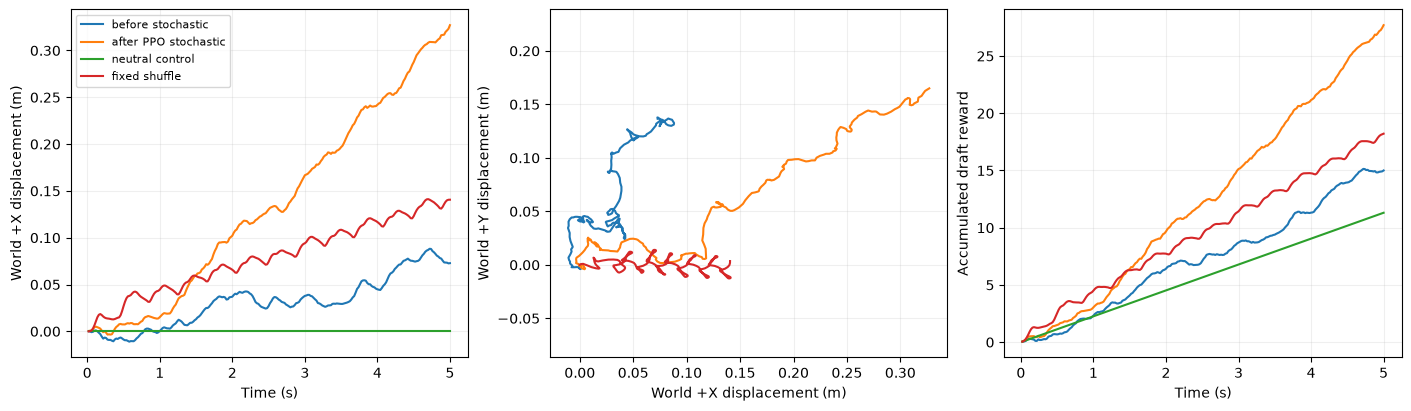

In [36]:
def evaluate_ppo():
    folder = ppo_directory/f'evaluation-{ppo_updates:05d}-{datetime.now(timezone.utc).strftime("%H%M%S%f")}'
    folder.mkdir()
    evaluations = []
    for seed in PPO['eval_seeds']:
        for label, network in [('before stochastic',initial_actor), ('after PPO stochastic',actor),
                               ('REINFORCE n=20 stochastic',reinforce_actor)]:
            evaluations.append(collect(network, observation_from, sample_action, reward_terms,
                                       SETTINGS, seed=seed, label=label))
    for label, network in [('before mean',initial_actor), ('after PPO mean',actor),
                           ('REINFORCE n=20 mean',reinforce_actor)]:
        evaluations.append(collect(network, observation_from, sample_action, reward_terms,
            dict(SETTINGS, deterministic=True), seed=PPO['eval_seeds'][0], label=label))
    for label, control in [('neutral control',lambda s:np.zeros(18)),('fixed shuffle',geometry_gait)]:
        evaluations.append(collect(None, observation_from, sample_action, reward_terms, SETTINGS,
            seed=PPO['eval_seeds'][0], label=label, control=control))
    for index, episode in enumerate(evaluations):
        save_episode(episode, folder/f'{index:02d}')
    table = pd.DataFrame([summary(e) for e in evaluations])
    table.to_csv(folder/'comparison.csv', index=False)
    selected = [evaluations[i] for i in (0,1,-2,-1)]
    launch_replay_grid([e['recording'].replay for e in selected], folder/'views', speed=1)
    display(table)
    plot_evaluations(selected)
    return table

ppo_evaluation = evaluate_ppo()

## 9 · Continue from 50 to 100 total updates

Run after section 7. Keep the same actor, critic, optimizer states, task and reward.
This adds 50 updates after n=50; it does not start a second independent run.
Then run the Checkpoint comparison definitions and evaluation cell below.
No behavioral result is claimed by this prepared code.


In [37]:
assert TRAINING_UPDATES == 50 and TOTAL_UPDATES == 100
assert 50 <= ppo_updates <= 100, 'Run section 7 first; use a run at or before n=100.'
assert (ppo_directory / 'checkpoint-00050.pt').is_file(), 'Missing n=50 checkpoint.'
if ppo_updates < TOTAL_UPDATES:
    train_ppo_block(TOTAL_UPDATES - ppo_updates)
assert (ppo_directory / 'checkpoint-00100.pt').is_file(), 'Missing n=100 checkpoint.'
print(f'PPO n={ppo_updates}. Ready for Checkpoint comparison in {ppo_directory}.')


{'update': 51, 'epochs': 2, 'approx_kl': 0.024886224418878555, 'clip_fraction': 0.3569999933242798, 'value_mse': 1.9545577764511108, 'explained_variance': 0.004520118236541748, 'latent_entropy': 3.869382381439209, 'ratio_min': 0.49522051215171814, 'ratio_max': 1.9992419481277466, 'forward_m': np.float64(0.32191624516786543), 'falls': 0}
{'update': 52, 'epochs': 2, 'approx_kl': 0.017943229526281357, 'clip_fraction': 0.2619999945163727, 'value_mse': 1.9359055757522583, 'explained_variance': 0.02212369441986084, 'latent_entropy': 3.869382381439209, 'ratio_min': 0.4855179786682129, 'ratio_max': 1.947546124458313, 'forward_m': np.float64(0.3008981042470678), 'falls': 0}
{'update': 53, 'epochs': 2, 'approx_kl': 0.02108808606863022, 'clip_fraction': 0.29600000381469727, 'value_mse': 1.9427319765090942, 'explained_variance': 0.012848258018493652, 'latent_entropy': 3.869382381439209, 'ratio_min': 0.4887666404247284, 'ratio_max': 2.0607030391693115, 'forward_m': np.float64(0.290828377597133), 'f

### Checkpoint comparison · PPO n=50 vs n=100

After sections 7 and 9, run the definitions and evaluation cell below.
Evaluation loads saved weights from the current `ppo_directory`; it does not train.
Both checkpoints use the same 12 seeds, task, reward and observation functions.

| Viewer row | Left | Right |
| --- | --- | --- |
| Top | n=50 sampled | n=100 sampled |
| Bottom | n=50 mean action | n=100 mean action |

The four panes share the first declared seed and playback clock. Space pauses;
R restarts; arrows and +/- change the shared camera. CSV measurements stay beside
recorded replays. These are development seeds, not a new capability claim.


In [38]:
def evaluate_checkpoints(checkpoints):
    # Check every file before collecting any rollouts. Never modify the live actor.
    paths = {
        step: ppo_directory / ('initial.pt' if step == 0 else f'checkpoint-{step:05d}.pt')
        for step in checkpoints
    }
    missing = [step for step, path in paths.items() if not path.exists()]
    if missing:
        raise FileNotFoundError(f'Missing checkpoints in {ppo_directory}: {missing}')

    saved_checkpoints = {step: torch.load(path, weights_only=True) for step, path in paths.items()}
    for step, saved in saved_checkpoints.items():
        assert saved['updates'] == step, f'Checkpoint update mismatch: {step}'
        assert saved['settings'] == SETTINGS and saved['ppo'] == PPO, 'Keep task and PPO settings fixed.'
        assert saved['reward'] == REWARD, 'Keep reward weights fixed.'

    folder = ppo_directory / f'checkpoint-comparison-{datetime.now(timezone.utc).strftime("%H%M%S%f")}'
    folder.mkdir()
    records, replays = [], {}
    for step, path in paths.items():
        saved = saved_checkpoints[step]
        network = copy.deepcopy(actor)
        network.load_state_dict(saved['actor'])
        network.eval()
        task = saved.get('settings', SETTINGS)
        for mode in ('sampled', 'mean'):
            for seed in PPO['eval_seeds']:
                episode = collect(
                    network, observation_from, sample_action, reward_terms,
                    dict(task, deterministic=(mode == 'mean')), seed=seed,
                    label=f'PPO n={step} | {mode} | seed={seed}',
                )
                save_episode(episode, folder / f'n{step:05d}-{mode}-{seed}')
                records.append(dict(update=step, mode=mode, **summary(episode)))
                if seed == PPO['eval_seeds'][0]:
                    replays[step, mode] = episode['recording'].replay
        print(f'Evaluated PPO n={step}: sampled and mean, {len(PPO["eval_seeds"])} paired seeds')

    table = pd.DataFrame(records)
    table.to_csv(folder / 'comparison.csv', index=False)
    report = table.assign(
        forward_mm=1000 * table.forward_m,
        abs_lateral_mm=1000 * table.sideways_m.abs(),
    ).groupby(['update', 'mode']).agg(
        forward_mean_mm=('forward_mm', 'mean'),
        forward_min_mm=('forward_mm', 'min'),
        forward_max_mm=('forward_mm', 'max'),
        lateral_mean_mm=('abs_lateral_mm', 'mean'),
        falls=('terminated', 'sum'),
    )
    display(report)
    if 50 in checkpoints and 100 in checkpoints:
        # Top: sampled n=50 / n=100. Bottom: mean n=50 / n=100.
        launch_replay_grid(
            [replays[step, mode] for mode in ('sampled', 'mean') for step in (50, 100)],
            folder / 'views', speed=1,
        )
        paired = table[table['update'].isin([50, 100])].pivot(
            index=['mode', 'seed'], columns='update', values='forward_m',
        )
        display((1000 * (paired[100] - paired[50])).rename('n100_minus_n50_forward_mm'))
    print('Saved comparison:', folder)
    return table


In [39]:
# EVALUATE AND OPEN THE FOUR-PANE VIEWER. No training in this cell.
# Use the current run from sections 7 and 9; no hard-coded run or automatic resume.
assert EVAL_CHECKPOINTS == [50, 100]
checkpoint_comparison = evaluate_checkpoints(EVAL_CHECKPOINTS)


Evaluated PPO n=50: sampled and mean, 12 paired seeds
Evaluated PPO n=100: sampled and mean, 12 paired seeds


forward_mean_mm  forward_min_mm  forward_max_mm  \
update mode                                                       
50     mean            2.870772        2.870772        2.870772   
       sampled       305.035848      224.077600      363.122553   
100    mean         1894.137250     1894.137250     1894.137250   
       sampled      1371.379505     1296.872703     1504.705918   

                lateral_mean_mm  falls  
update mode                             
50     mean            2.184540      0  
       sampled        83.428034      0  
100    mean          101.235448      0  
       sampled        98.392465      0

Four-pane replay opened (PID 34128): C:\Users\haidm\Desktop\robotics\spider\telemetry\ppo\20260915T152940537445Z\checkpoint-comparison-153230927015\views\grid-x40c9o7u


mode     seed
mean     201     1891.266478
         202     1891.266478
         203     1891.266478
         204     1891.266478
         205     1891.266478
         206     1891.266478
         207     1891.266478
         208     1891.266478
         209     1891.266478
         210     1891.266478
         211     1891.266478
         212     1891.266478
sampled  201     1177.650581
         202     1054.646998
         203     1060.038527
         204     1016.072469
         205     1003.231097
         206     1091.963436
         207     1143.473702
         208     1014.028011
         209     1087.165524
         210     1101.501592
         211     1032.222087
         212     1014.129857
Name: n100_minus_n50_forward_mm, dtype: float64

Saved comparison: c:\Users\haidm\Desktop\robotics\spider\telemetry\ppo\20260915T152940537445Z\checkpoint-comparison-153230927015


# Reference · preserved REINFORCE cells and outputs

Not part of the PPO execution path. These are the saved baseline cells, unchanged.
The full pre-refactor notebook (including optional MDP stubs) is archived above.

## Train -> watch -> debug

1. Initialize a fresh run.
2. Edit the learning functions.
3. Run a training block, then evaluation/replay.
4. Inspect `last_batch`, `training_log`, `credit_log`, and `gradient_log`.

Rerun training to continue weights. Reinitialize for a fresh comparison. Save before each block.
The actor learns 18 joint offsets; the fixed shuffle is only a control. No answer key.
Collection and logging live in `lab/reinforce_inspection.py`.

In [40]:
# INITIALIZE A FRESH RUN. Rerunning resets learning; no robot rollout runs here.
import copy
from pathlib import Path
import numpy as np
import pandas as pd
import inspect
import hashlib
import json
from datetime import datetime, timezone
from importlib.metadata import version
import torch
from torch import nn
from torch.distributions import Normal
from IPython.display import display
from lab.reinforce_inspection import collect, summary, save_episode, gradient_table, plot_evaluations

SETTINGS = dict(horizon=250, physics_steps=10, bound_rad=0.05, std=0.30,
                fall_height_m=0.25, gamma=0.99, learning_rate=3e-4,
                batch_episodes=4, initialization_seed=23, train_seed=1000,
                eval_seeds=[101, 102, 103], deterministic=False)
# Draft finite-horizon task: fall/horizon ends rewards; no bootstrap.
# Start with notebook 03's 0.05 rad bound. Settings remain editable.

with torch.random.fork_rng(devices=[]):
    torch.manual_seed(SETTINGS['initialization_seed'])
    actor = nn.Sequential(nn.Linear(47, 64), nn.Tanh(), nn.Linear(64, 64),
                          nn.Tanh(), nn.Linear(64, 18))
optimizer = torch.optim.Adam(actor.parameters(), lr=SETTINGS['learning_rate'])
initial_actor = copy.deepcopy(actor)
updates = 0
training_log, credit_log, gradient_log = [], [], []
run_directory = REPO_ROOT / 'telemetry' / 'reinforce-debug' / datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
run_directory.mkdir(parents=True, exist_ok=False)
(run_directory / 'settings.json').write_text(json.dumps(SETTINGS, indent=2), encoding='utf-8')
torch.save({'actor': actor.state_dict(), 'optimizer': optimizer.state_dict(), 'updates': updates},
           run_directory / 'initial.pt')
receipt = dict(torch=version('torch'), mujoco=version('mujoco'),
               actor=repr(actor), helper_sha256=hashlib.sha256(
               (Path(inspect.getfile(collect))).read_bytes()).hexdigest())
(run_directory / 'environment.json').write_text(json.dumps(receipt, indent=2), encoding='utf-8')
print('Fresh run:', run_directory)
print(SETTINGS)
print('Action duration (s):', SETTINGS['physics_steps'] * sim.model.opt.timestep)

Fresh run: c:\Users\haidm\Desktop\robotics\spider\telemetry\reinforce-debug\20260915T153249989821Z
{'horizon': 250, 'physics_steps': 10, 'bound_rad': 0.05, 'std': 0.3, 'fall_height_m': 0.25, 'gamma': 0.99, 'learning_rate': 0.0003, 'batch_episodes': 4, 'initialization_seed': 23, 'train_seed': 1000, 'eval_seeds': [101, 102, 103], 'deterministic': False}
Action duration (s): 0.02


### Observation layout

47 raw values. If the size changes, update the actor and reinitialize.

| Slice | Component | Units / order |
| --- | --- | --- |
| 0:3 | Torso linear velocity | m/s, world XYZ |
| 3:6 | Torso angular velocity | rad/s, free-joint `qvel[3:6]` |
| 6:10 | Orientation | quaternion wxyz |
| 10:28 | Joint angles | rad, actuator order |
| 28:46 | Joint velocities | rad/s, actuator order |
| 46:47 | Height | m, world Z |

`episode_end` marks each episode's last row. Logs distinguish latent actions from joint commands.

In [41]:
# EDITABLE LEARNING FUNCTIONS. No training executes in this cell.
def observation_from(state):
    return torch.tensor([*state.torso_velocity, *state.torso_angular_velocity,
                         *state.torso_orientation, *state.joint_positions,
                         *state.joint_velocities, state.torso_position[2]], dtype=torch.float32)


def sample_action(network, observation, std, deterministic=False):
    distribution = Normal(network(observation), std)
    latent = distribution.mean if deterministic else distribution.sample()
    log_prob = distribution.log_prob(latent).sum()
    return latent, log_prob


def reward_terms(before, offsets_rad, after):
    return {
        'progress': float(after.torso_velocity[0]),
        'height': 0.1 * float(after.torso_position[2]),
    }


def reward_to_go(rewards, episode_end, gamma):
    returns = torch.empty_like(rewards)
    future = rewards.new_zeros(())
    for t in range(len(rewards) - 1, -1, -1):
        if episode_end[t]:
            future = rewards[t].new_zeros(())
        future = rewards[t] + gamma * future
        returns[t] = future
    return returns


def reinforce_loss(log_probs, returns):
    weights = (returns - returns.mean()) / (returns.std(unbiased=False) + 1e-8)
    return -(log_probs * weights.detach()).mean()

In [42]:
# TRAIN A BOUNDED BLOCK. Actual robot physics and optimizer steps happen here.
UPDATES_THIS_BLOCK = 20
block_directory = run_directory / f'block-{updates:05d}'
block_directory.mkdir(parents=True, exist_ok=False)
# Preserve saved notebook source plus live function source when available in IPython.
(block_directory / 'notebook.ipynb').write_bytes(
    (REPO_ROOT / 'lab/notebooks/04_mdp_contract.ipynb').read_bytes())
source_receipt = {}
for function in (observation_from, sample_action, reward_terms, reward_to_go, reinforce_loss):
    try:
        source_receipt[function.__name__] = inspect.getsource(function)
    except (OSError, TypeError):
        source_receipt[function.__name__] = 'Source unavailable; see saved notebook snapshot.'
(block_directory / 'learning-functions.json').write_text(json.dumps(source_receipt, indent=2), encoding='utf-8')
(block_directory / 'settings.json').write_text(json.dumps(SETTINGS, indent=2), encoding='utf-8')
for _ in range(UPDATES_THIS_BLOCK):
    last_batch = []
    for episode_index in range(SETTINGS['batch_episodes']):
        seed = SETTINGS['train_seed'] + updates * SETTINGS['batch_episodes'] + episode_index
        episode = collect(actor, observation_from, sample_action, reward_terms, SETTINGS,
                          seed=seed, label=f'train update {updates} episode {episode_index}', track_grad=True)
        last_batch.append(episode)
        save_episode(episode, block_directory / f'update-{updates:05d}-episode-{episode_index}')

    rows = [row for episode in last_batch for row in episode['rows']]
    rewards = torch.tensor([row['reward'] for row in rows], dtype=torch.float32)
    episode_end = torch.tensor([row['terminated'] or row['truncated'] for row in rows])
    log_probs = torch.stack([row['log_prob'] for row in rows])
    returns = reward_to_go(rewards, episode_end, SETTINGS['gamma'])
    loss = reinforce_loss(log_probs, returns)
    before_weights = copy.deepcopy(actor.state_dict())
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    gradients = gradient_table(actor).assign(update=updates)
    optimizer.step()
    weight_change = float(torch.sqrt(sum((actor.state_dict()[k] - before_weights[k]).square().sum()
                                        for k in before_weights)))
    batch_credit = pd.DataFrame(dict(
        update=updates, row=np.arange(len(rows)), episode=np.repeat(np.arange(len(last_batch)),
        [len(e['rows']) for e in last_batch]), reward=rewards.numpy(),
        episode_end=episode_end.numpy(), log_prob=log_probs.detach().numpy(),
        return_used=returns.detach().numpy()))
    credit_log.append(batch_credit)
    gradient_log.append(gradients)
    for episode in last_batch:
        training_log.append(dict(update=updates, loss=float(loss.detach()),
                                 weight_change_l2=weight_change, **summary(episode)))
    batch_credit.to_csv(block_directory / f'credit-{updates:05d}.csv', index=False)
    gradients.to_csv(block_directory / f'gradients-{updates:05d}.csv', index=False)
    print(f'update={updates} | loss={float(loss.detach()):.6g} | weight change={weight_change:.6g}')
    updates += 1
    torch.save(dict(actor=actor.state_dict(), optimizer=optimizer.state_dict(), updates=updates,
                    settings=SETTINGS), block_directory / f'checkpoint-{updates:05d}.pt')
    # Retain data for inspection without keeping consumed autograd graphs alive. 
    for row in rows:
        row['log_prob'] = row['log_prob'].detach()
    del loss, log_probs, returns

pd.DataFrame(training_log).to_csv(run_directory / 'training.csv', index=False)
display(pd.DataFrame(training_log).tail(8))
display(gradient_log[-1])
display(credit_log[-1].head(12))
print('Inspect: last_batch, credit_log, gradient_log. Next: evaluate and replay.')

update=0 | loss=-0.00983416 | weight change=0.0274972
update=1 | loss=0.0606991 | weight change=0.0197436
update=2 | loss=-0.0253844 | weight change=0.0158846
update=3 | loss=-0.0349905 | weight change=0.0142074
update=4 | loss=-0.0153915 | weight change=0.0127355
update=5 | loss=0.0229728 | weight change=0.0114336
update=6 | loss=-0.0684287 | weight change=0.0111045
update=7 | loss=-0.0558795 | weight change=0.0101624
update=8 | loss=-0.113218 | weight change=0.00910196
update=9 | loss=-0.191015 | weight change=0.00825092
update=10 | loss=0.118289 | weight change=0.00813521
update=11 | loss=-0.0541111 | weight change=0.00797822
update=12 | loss=0.0222179 | weight change=0.00842889
update=13 | loss=0.144753 | weight change=0.00806038
update=14 | loss=-0.112965 | weight change=0.00804425
update=15 | loss=0.10568 | weight change=0.00777643
update=16 | loss=-0.0666559 | weight change=0.00770236
update=17 | loss=-0.0443527 | weight change=0.00773837
update=18 | loss=-0.0139156 | weight cha

,update,loss,weight_change_l2,treatment,seed,seconds,forward_m,sideways_m,minimum_height_m,total_reward,terminated,truncated,clipped_targets
72,18,-0.013916,0.008137,train update 18 episode 0,1072,5.0,-0.038297,-0.019346,0.449038,9.441131,False,True,0
73,18,-0.013916,0.008137,train update 18 episode 1,1073,5.0,0.030906,0.041365,0.448406,12.822786,False,True,0
74,18,-0.013916,0.008137,train update 18 episode 2,1074,5.0,-0.032496,0.001635,0.448901,9.671530,False,True,0
75,18,-0.013916,0.008137,train update 18 episode 3,1075,5.0,0.064520,0.064591,0.448602,14.510547,False,True,0
76,19,0.095749,0.007780,train update 19 episode 0,1076,5.0,0.050766,0.066337,0.448759,13.831546,False,True,0
77,19,0.095749,0.007780,train update 19 episode 1,1077,5.0,-0.003254,0.038956,0.449409,11.195767,False,True,0
78,19,0.095749,0.007780,train update 19 episode 2,1078,5.0,0.069390,-0.037875,0.447658,14.821088,False,True,0
79,19,0.095749,0.007780,train update 19 episode 3,1079,5.0,0.012708,0.045905,0.447226,12.013417,False,True,0


,parameter,weight_norm,grad_norm,update
0,0.weight,4.637475,0.704212,19
1,0.bias,0.711845,0.115691,19
2,2.weight,4.576616,0.867065,19
3,2.bias,0.530798,0.234248,19
4,4.weight,2.486627,0.987156,19
5,4.bias,0.356514,0.454346,19


,update,row,episode,reward,episode_end,log_prob,return_used
0,19,0,0,0.047238,False,-10.083288,5.652919
1,19,1,0,0.043403,False,-6.913671,5.662304
2,19,2,0,0.013315,False,-2.397288,5.675657
3,19,3,0,-0.014789,False,-0.735343,5.719538
4,19,4,0,0.047006,False,-2.950133,5.792249
5,19,5,0,0.103167,False,-4.929440,5.803275
6,19,6,0,0.076229,False,-5.082410,5.757685
7,19,7,0,0.204336,False,-6.130293,5.738844
8,19,8,0,0.077144,False,-1.724556,5.590412
9,19,9,0,0.071938,False,-3.568493,5.568957


Inspect: last_batch, credit_log, gradient_log. Next: evaluate and replay.


Four-pane replay opened (PID 30820): C:\Users\haidm\Desktop\robotics\spider\telemetry\reinforce-debug\20260915T153249989821Z\evaluation-00020-153329043500\views\grid-koj2d6zi


,treatment,seed,seconds,forward_m,sideways_m,minimum_height_m,total_reward,terminated,truncated,clipped_targets
0,before stochastic seed 101,101,5.0,2.670706e-03,5.052042e-02,0.448040,11.507799,False,True,0
1,after stochastic seed 101,101,5.0,3.971743e-02,1.320912e-02,0.447924,13.349099,False,True,0
2,before stochastic seed 102,102,5.0,-1.144357e-02,1.272908e-02,0.447299,10.755969,False,True,0
3,after stochastic seed 102,102,5.0,7.872953e-04,1.548180e-03,0.449217,11.353286,False,True,0
4,before stochastic seed 103,103,5.0,2.948264e-02,-4.809390e-02,0.447859,12.776804,False,True,0
5,after stochastic seed 103,103,5.0,6.340801e-02,2.597824e-02,0.447733,14.518248,False,True,0
6,before mean,101,5.0,6.188571e-04,-1.696917e-03,0.449648,11.344728,False,True,0
7,after mean,101,5.0,7.502687e-04,-1.480910e-03,0.449711,11.352178,False,True,0
8,neutral control,101,5.0,-1.680008e-16,1.559862e-16,0.449502,11.308304,False,True,0
9,fixed shuffle,101,5.0,1.406082e-01,3.544754e-03,0.448313,18.216867,False,True,0


Saved evaluation: c:\Users\haidm\Desktop\robotics\spider\telemetry\reinforce-debug\20260915T153249989821Z\evaluation-00020-153329043500


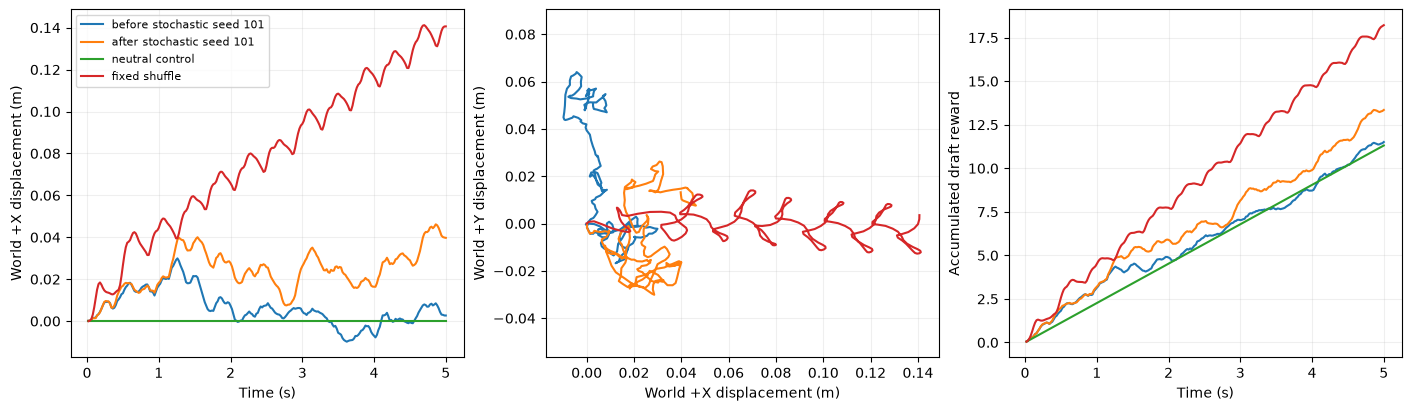

In [43]:
# EVALUATE: no weight updates. Keep seeds/settings fixed between comparisons.
evaluation_directory = run_directory / f'evaluation-{updates:05d}-{datetime.now(timezone.utc).strftime("%H%M%S%f")}'
evaluation_directory.mkdir(parents=True, exist_ok=False)
evaluations = []
for seed in SETTINGS['eval_seeds']:
    for label, network in (('before', initial_actor), ('after', actor)):
        evaluations.append(collect(network, observation_from, sample_action, reward_terms, SETTINGS,
                                   seed=seed, label=f'{label} stochastic seed {seed}'))
for label, network in (('before mean', initial_actor), ('after mean', actor)):
    evaluations.append(collect(network, observation_from, sample_action, reward_terms,
                               dict(SETTINGS, deterministic=True), seed=SETTINGS['eval_seeds'][0], label=label))
for label, control in (('neutral control', lambda state: np.zeros(18)), ('fixed shuffle', geometry_gait)):
    evaluations.append(collect(None, observation_from, sample_action, reward_terms, SETTINGS,
                               seed=SETTINGS['eval_seeds'][0], label=label, control=control))
for index, episode in enumerate(evaluations):
    save_episode(episode, evaluation_directory / f'{index:02d}')
evaluation_table = pd.DataFrame([summary(e) for e in evaluations])
evaluation_table.to_csv(evaluation_directory / 'comparison.csv', index=False)
# Select one paired seed and controls for replay. Other recordings remain available.
view_episodes = [evaluations[0], evaluations[1], evaluations[-2], evaluations[-1]]
# Replays open before the score comparison, so motion stays beside its measurements.  
# viewers = [e['recording'].watch(evaluation_directory / 'views', speed=0.5) for e in view_episodes] 
from spider.recording import launch_replay_grid
viewer = launch_replay_grid(
    [e['recording'].replay for e in view_episodes],
    evaluation_directory / 'views', speed=0.5,
)
display(evaluation_table)
plot_evaluations(view_episodes)
print('Saved evaluation:', evaluation_directory)

### Evidence

Compare fixed seeds, deterministic policies, and controls. Inspect forward/sideways motion,
contacts, falls, and reward terms. A higher score is not proof of walking.

Preserve REINFORCE checkpoints and failures. Keep the task and evaluation fixed when changing
algorithms. Use [TODO.md](../../TODO.md) for walking acceptance and population evaluation.